# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Day 3 Task

This notebook analyzes mutual fund datasets using Python, Pandas, Matplotlib, Seaborn, and Plotly.

In [51]:
import os
print(os.getcwd())

c:\Users\balug\OneDrive\Desktop\Mutual_Fund_Analytics\notebooks


In [52]:
import os
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip_nav.csv', 'ICICI_Bluechip_nav.csv', 'Kotak_Bluechip_nav.csv', 'Nippon_Large_Cap_nav.csv', 'SBI_Bluechip_nav.csv']


In [53]:
import pandas as pd

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")


In [54]:
nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [55]:
print(nav_history.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


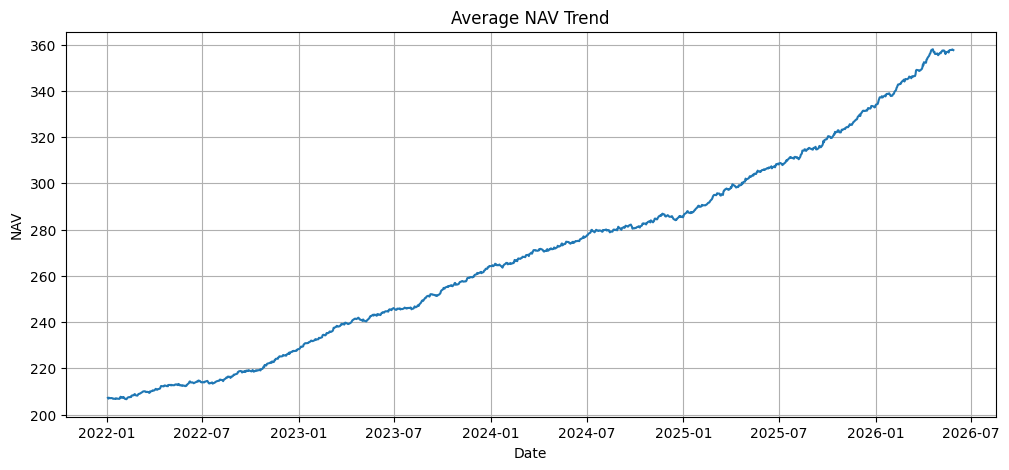

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
nav_history['date'] = pd.to_datetime(nav_history['date'])
avg_nav = nav_history.groupby('date')['nav'].mean()
plt.figure(figsize=(12,5))
plt.plot(avg_nav.index, avg_nav.values)
plt.title("Average NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.show()

In [57]:
print("Finding: Average NAV shows the overall trend of mutual fund performance over time.")

Finding: Average NAV shows the overall trend of mutual fund performance over time.


In [58]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
print(aum.info())
print(aum.columns)

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB
None
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


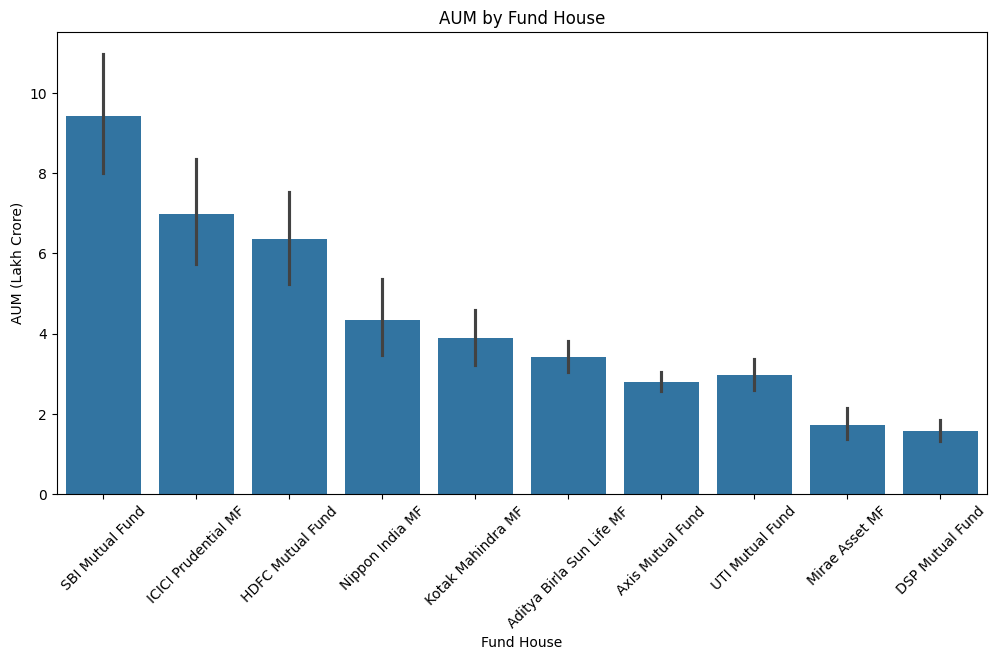

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
aum['date'] = pd.to_datetime(aum['date'])
plt.figure(figsize=(12,6))
sns.barplot(data=aum, x='fund_house', y='aum_lakh_crore')
plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)
plt.show()

In [60]:
print("Finding: Some fund houses manage significantly higher AUM than others.")

Finding: Some fund houses manage significantly higher AUM than others.


In [61]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
print(sip.info())
print(sip.columns)

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB
None
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [62]:
import pandas as pd
import plotly.express as px
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflow Trend',
    markers=True
)
fig.show()

In [63]:
print("Finding: SIP inflows show how investor participation changes over time.")

Finding: SIP inflows show how investor participation changes over time.


In [64]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")
print(category.info())
print(category.columns)

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB
None
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


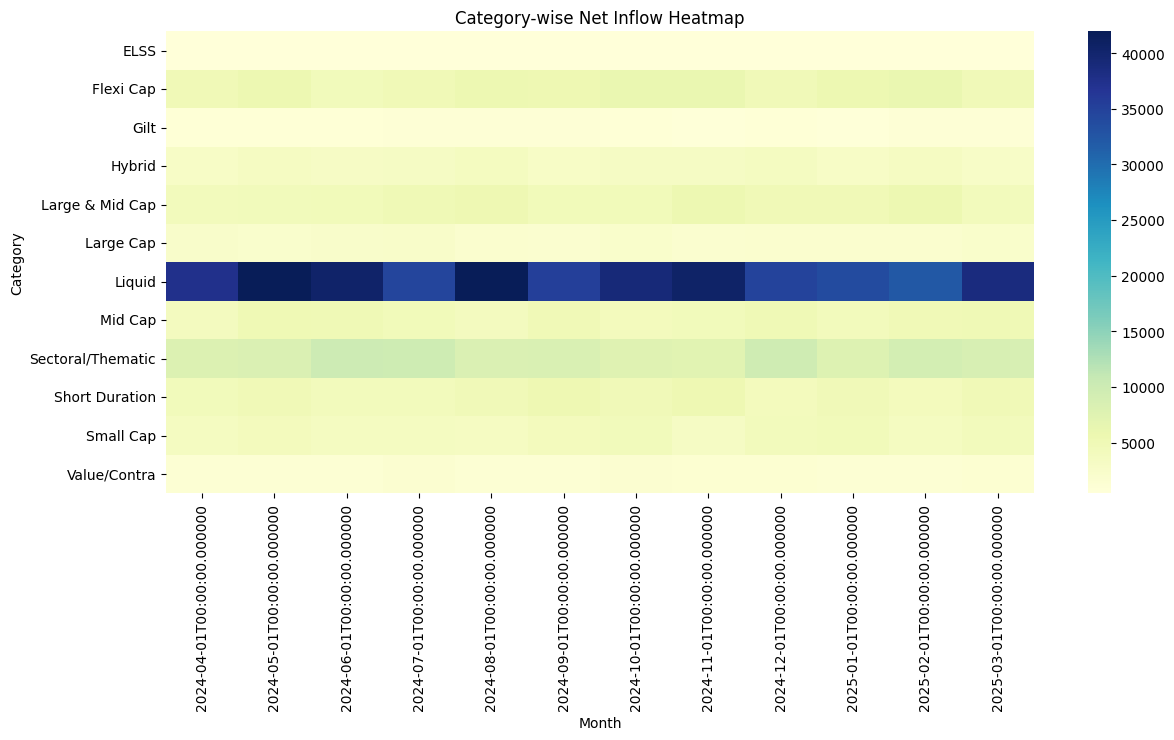

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
category['month'] = pd.to_datetime(category['month'])
pivot_table = category.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)
plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, cmap='YlGnBu')
plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")
plt.show()

In [66]:
print("Finding: Different mutual fund categories receive different levels of inflows over time.")

Finding: Different mutual fund categories receive different levels of inflows over time.


In [67]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.info())
print(folio.columns)

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB
None
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [68]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'Axis_Bluechip_nav.csv', 'ICICI_Bluechip_nav.csv', 'Kotak_Bluechip_nav.csv', 'Nippon_Large_Cap_nav.csv', 'SBI_Bluechip_nav.csv']


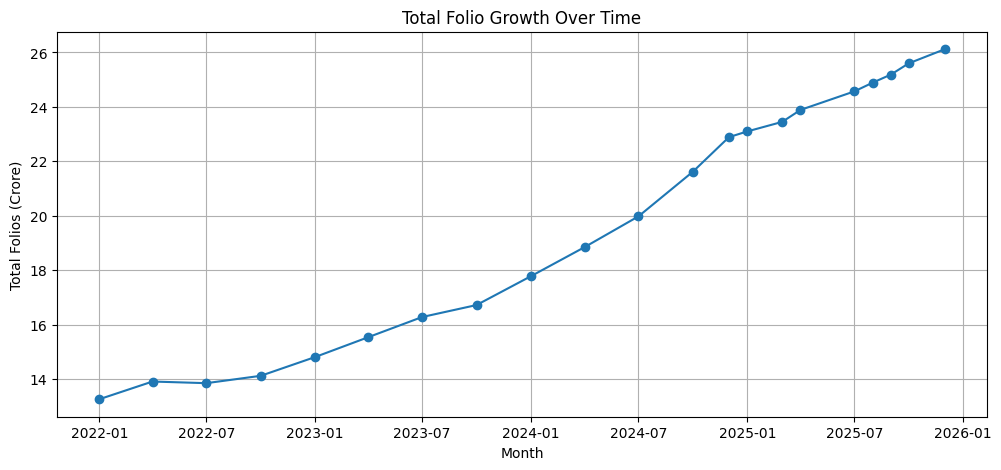

In [69]:
folio['month'] = pd.to_datetime(folio['month'])
plt.figure(figsize=(12,5))
plt.plot(folio['month'], folio['total_folios_crore'], marker='o')
plt.title("Total Folio Growth Over Time")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)
plt.show()

In [70]:
print("Finding: Total mutual fund folios show the growth of investor participation over time.")

Finding: Total mutual fund folios show the growth of investor participation over time.


In [71]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(holdings.info())
print(holdings.columns)

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB
None
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


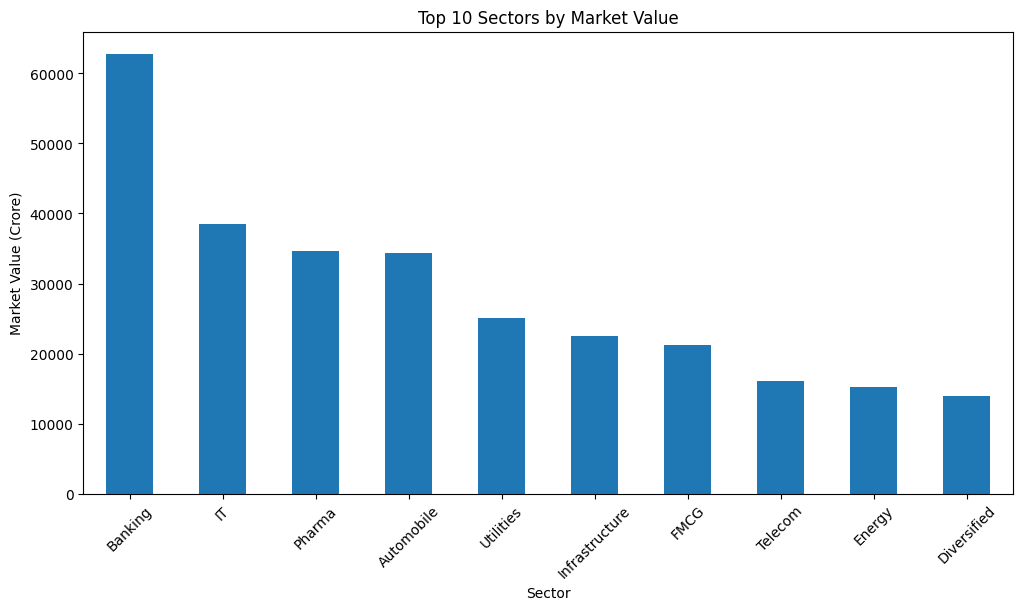

In [72]:
sector_mv = holdings.groupby('sector')['market_value_cr'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sector_mv.head(10).plot(kind='bar')
plt.title("Top 10 Sectors by Market Value")
plt.xlabel("Sector")
plt.ylabel("Market Value (Crore)")
plt.xticks(rotation=45)
plt.show()

In [73]:
print("Finding: A few sectors account for a large portion of portfolio investments.")

Finding: A few sectors account for a large portion of portfolio investments.


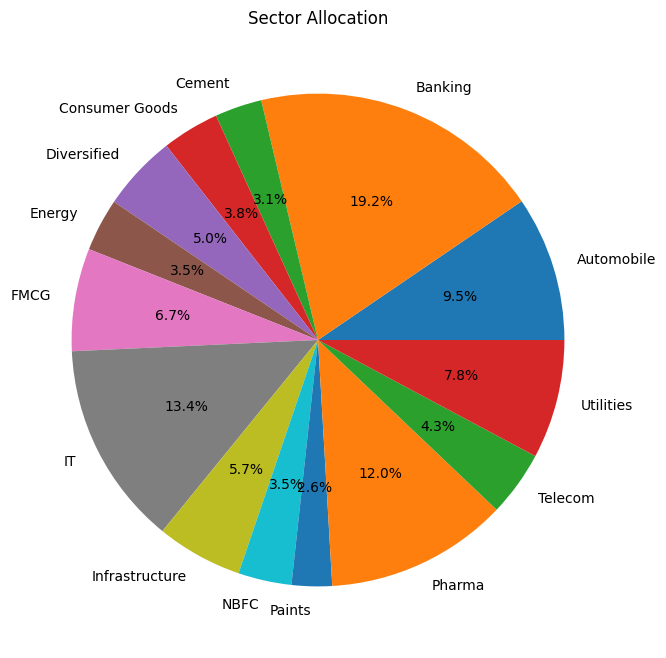

In [74]:
sector_weights = holdings.groupby('sector')['weight_pct'].sum()
plt.figure(figsize=(8,8))
plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%'
)
plt.title("Sector Allocation")
plt.show()

In [75]:
print("Finding: Portfolio allocation is concentrated in selected sectors.")

Finding: Portfolio allocation is concentrated in selected sectors.


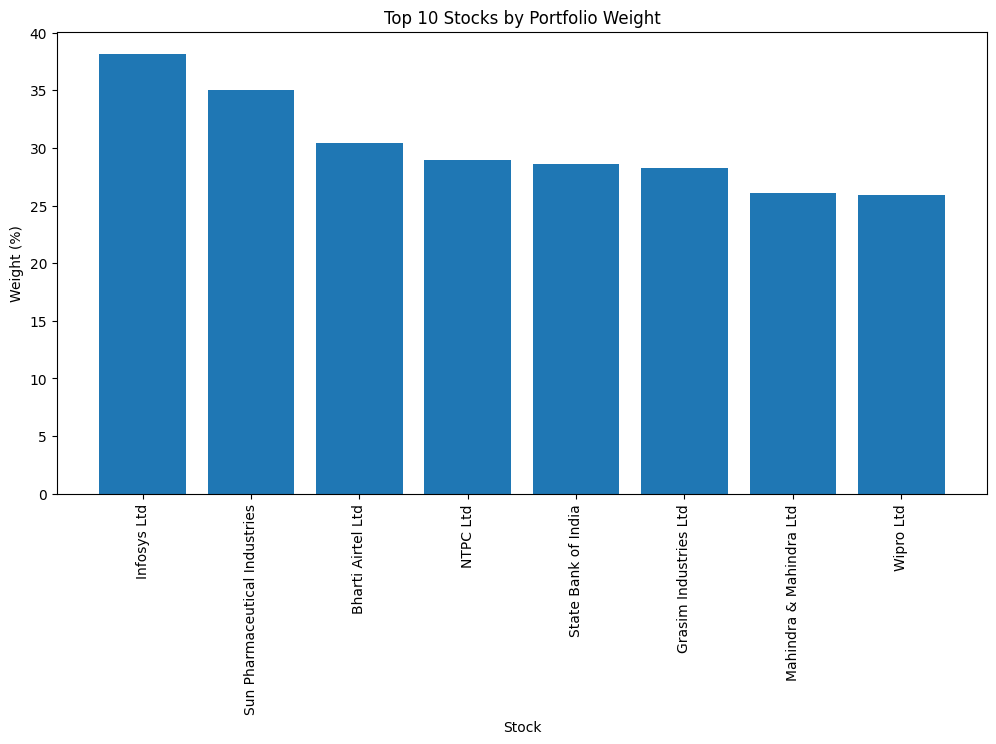

In [76]:
top_stocks = holdings.sort_values( by='weight_pct',ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.bar(top_stocks['stock_name'], top_stocks['weight_pct'])
plt.title("Top 10 Stocks by Portfolio Weight")
plt.xlabel("Stock")
plt.ylabel("Weight (%)")
plt.xticks(rotation=90)
plt.show()

In [77]:
print("Finding: A small number of stocks have higher portfolio weights.")

Finding: A small number of stocks have higher portfolio weights.


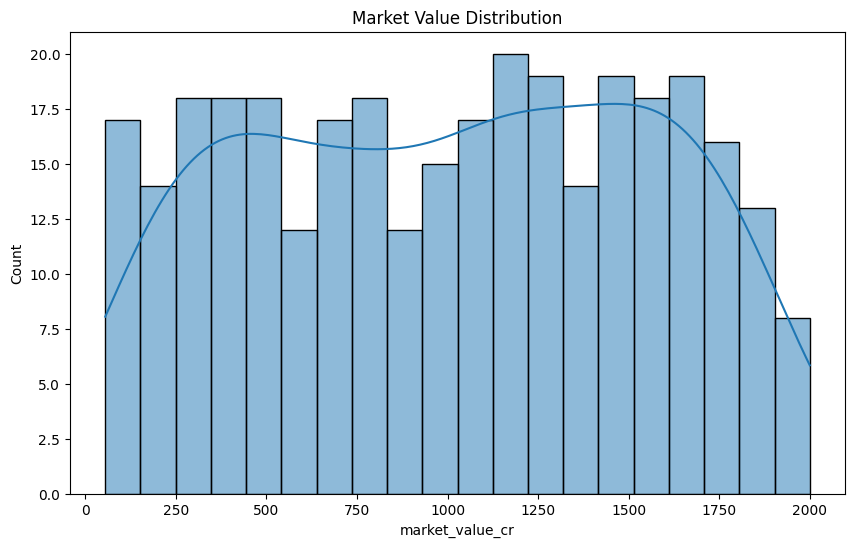

In [78]:
plt.figure(figsize=(10,6))
sns.histplot(
    holdings['market_value_cr'],
    bins=20,
    kde=True
)
plt.title("Market Value Distribution")
plt.show()

In [79]:
print("Finding: Most holdings are concentrated within a specific market value range.")

Finding: Most holdings are concentrated within a specific market value range.


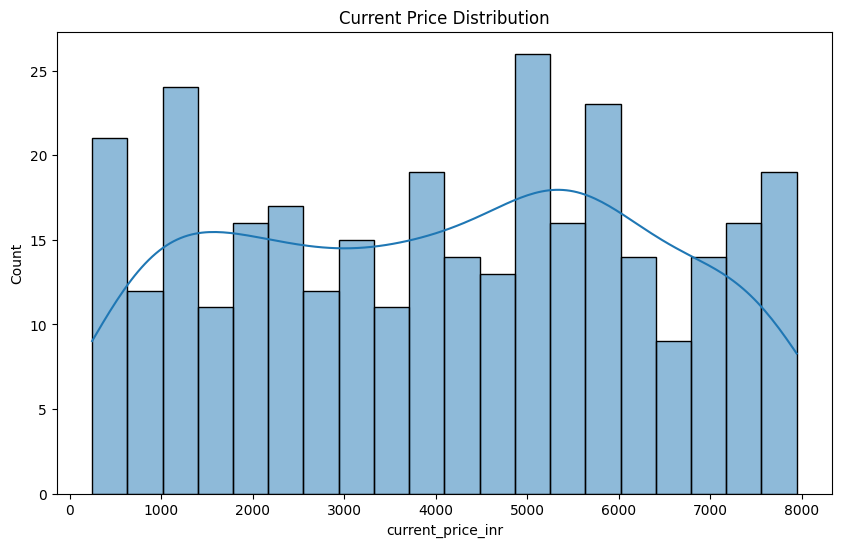

In [80]:
plt.figure(figsize=(10,6))
sns.histplot(
    holdings['current_price_inr'],
    bins=20,
    kde=True
)
plt.title("Current Price Distribution")
plt.show()

In [81]:
print("Finding: Stock prices vary significantly across holdings.")

Finding: Stock prices vary significantly across holdings.


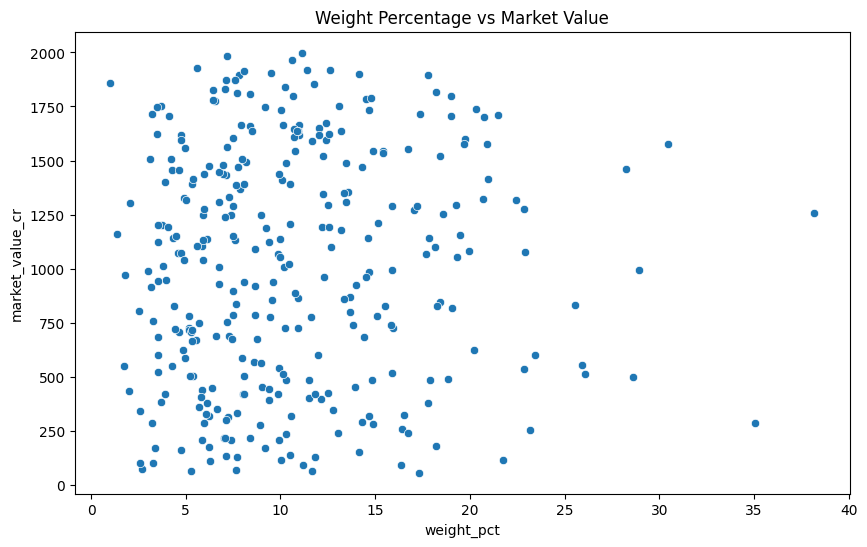

In [82]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=holdings,
    x='weight_pct',
    y='market_value_cr'
)
plt.title("Weight Percentage vs Market Value")
plt.show()

In [83]:
print("Finding: Holdings with larger weights generally tend to have higher market values.")

Finding: Holdings with larger weights generally tend to have higher market values.


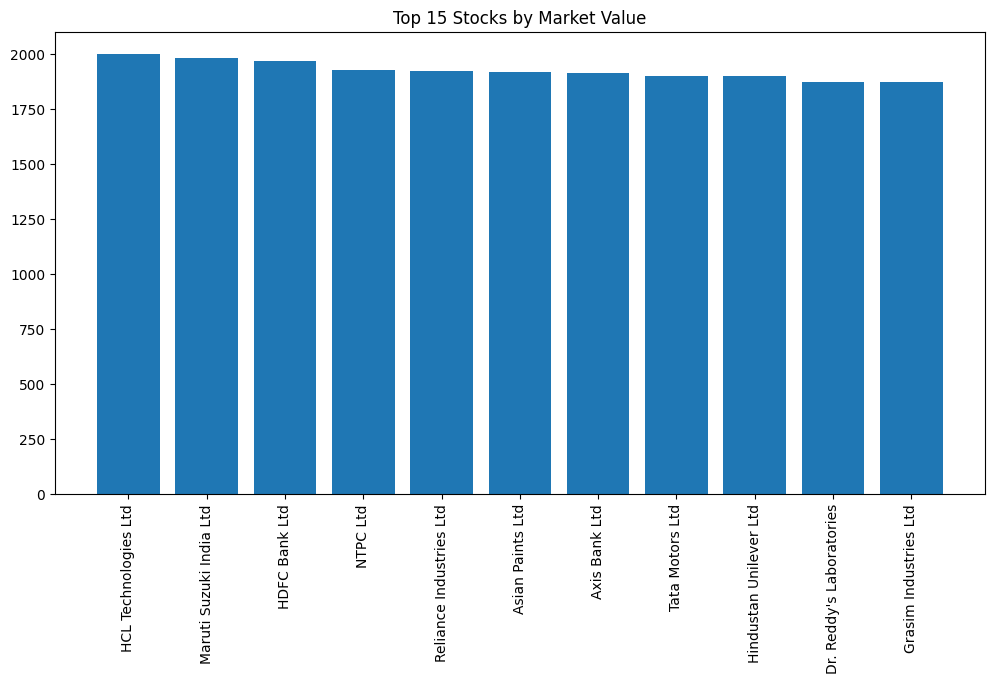

In [84]:
top_mv = holdings.sort_values(
    by='market_value_cr',
    ascending=False
).head(15)

plt.figure(figsize=(12,6))
plt.bar(top_mv['stock_name'], top_mv['market_value_cr'])
plt.title("Top 15 Stocks by Market Value")
plt.xticks(rotation=90)
plt.show()

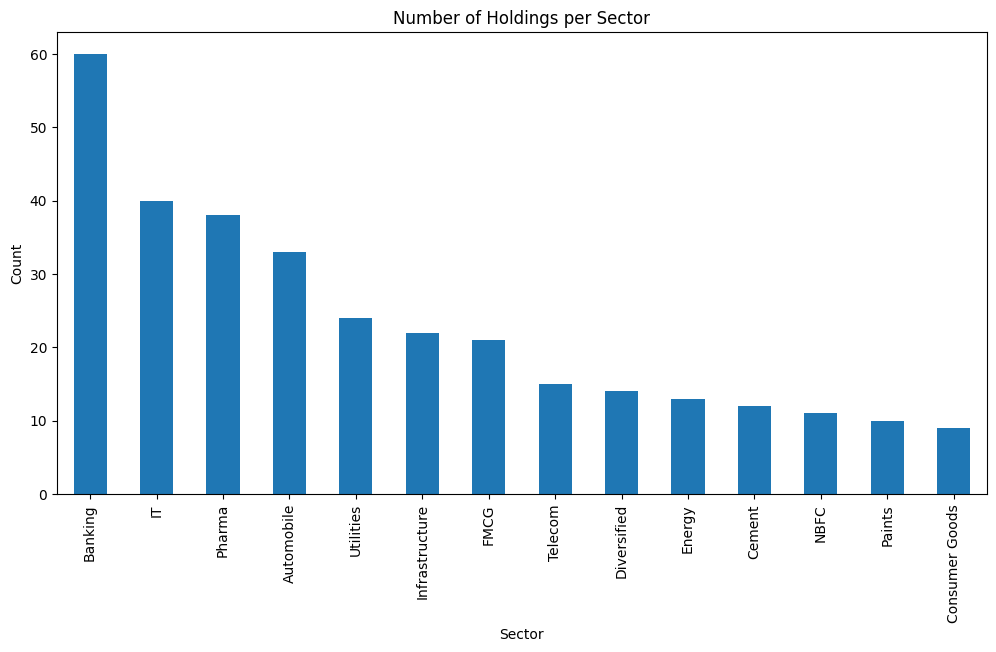

In [85]:
plt.figure(figsize=(12,6))
holdings['sector'].value_counts().plot(kind='bar')
plt.title("Number of Holdings per Sector")
plt.xlabel("Sector")
plt.ylabel("Count")
plt.show()

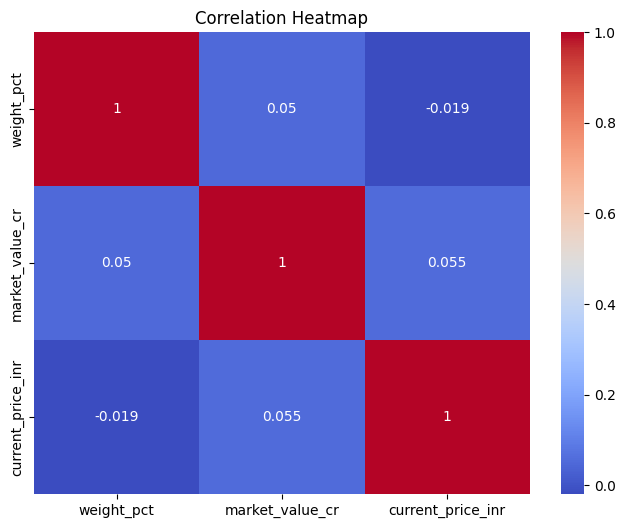

In [86]:
plt.figure(figsize=(8,6))
corr = holdings[
    ['weight_pct','market_value_cr','current_price_inr']
].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# Key Findings

1. Average NAV shows the long-term trend of mutual fund performance.
2. AUM varies significantly across fund houses.
3. SIP inflows indicate growing investor participation.
4. Category-wise inflows differ across time periods.
5. Total folios have grown steadily over time.
6. Equity folios contribute the largest share of investor accounts.
7. Portfolio investments are concentrated in a few sectors.
8. Sector allocation shows diversification across industries.
9. A small number of stocks have higher portfolio weights.
10. Market value distribution is uneven across holdings.